# Análisis SPARQL de entidades deportivas

Este notebook:
1. carga el RDF local,
2. ejecuta 2 consultas locales,
3. ejecuta una consulta extra por fecha de alta,
4. enriquece resultados con Wikidata,
5. genera gráficos y un mapa.



In [3]:
! pip install rdflib SPARQLWrapper pandas matplotlib folium

In [1]:
import sys
!{sys.executable} -m pip uninstall -y rdflib pyparsing
!{sys.executable} -m pip install rdflib==6.3.2 pyparsing==2.4.7

  Using cached rdflib-6.3.2-py3-none-any.whl.metadata (11 kB)
  Using cached pyparsing-2.4.7-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached rdflib-6.3.2-py3-none-any.whl (528 kB)
Using cached pyparsing-2.4.7-py2.py3-none-any.whl (67 kB)


In [2]:
from pathlib import Path
import pandas as pd
from rdflib import Graph
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt
import folium
from IPython.display import display, IFrame


PROJECT_ROOT = Path.cwd()
NT_PATH = PROJECT_ROOT / "mappings" / "knowledge-graph.nt"

QUERIES_DIR = PROJECT_ROOT / "queries"
RESULTS_DIR = PROJECT_ROOT / "results" / "query_results"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
MAPS_DIR = PROJECT_ROOT / "results" / "maps"

for p in [RESULTS_DIR, FIGURES_DIR, MAPS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEP = "http://example.org/def/dep#"
OWL = "http://www.w3.org/2002/07/owl#"

print("NT:", NT_PATH)

NT: c:\Users\yarac\sw-kg\teams\coso\mappings\knowledge-graph.nt


In [4]:
from urllib.parse import unquote, quote
import re

CLEAN_NT_PATH = PROJECT_ROOT / "mappings" / "clean_knowledge_graph.nt"

BAD_LINES_PATH = PROJECT_ROOT / "mappings" / "entidades_deportivas_bad_lines.txt"

triple_pattern = re.compile(r'^\s*<[^<>]*>\s+<[^<>]*>\s+(.+)\s+\.\s*$')

def clean_iri_token(token: str) -> str:
    token = token.strip()
    if token.startswith("<") and token.endswith(">"):
        iri = token[1:-1].strip()
        iri = unquote(iri)                     # decodifica http%3A...
        iri = quote(iri, safe=":/#?&=%._~-")   # vuelve a codificar espacios y raros
        return f"<{iri}>"
    return token

clean_lines = []
bad_lines = []

with open(NT_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for n, line in enumerate(f, start=1):
        raw = line.rstrip("\n")

        # Ignora vacías
        if not raw.strip():
            continue

        # Separa sujeto, predicado y el resto de forma simple
        parts = raw.strip().split(None, 2)

        # Necesitamos al menos sujeto, predicado y objeto+.
        if len(parts) < 3:
            bad_lines.append(f"Línea {n}: {raw}")
            continue

        s, p, rest = parts

        # El resto debe terminar en punto
        if not rest.strip().endswith("."):
            bad_lines.append(f"Línea {n}: {raw}")
            continue

        # quita el punto final
        obj = rest.strip()[:-1].strip()

        # limpia sujeto y predicado
        s = clean_iri_token(s)
        p = clean_iri_token(p)

        # limpia objeto según tipo
        if obj.startswith("<") and obj.endswith(">"):
            obj = clean_iri_token(obj)
        elif obj.startswith('"'):
            # literal: lo dejamos tal cual
            pass
        elif obj.startswith("_:"):
            # blank node
            pass
        else:
            # no parece un objeto N-Triples válido
            bad_lines.append(f"Línea {n}: {raw}")
            continue

        fixed = f"{s} {p} {obj} ."
        clean_lines.append(fixed)

with open(CLEAN_NT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(clean_lines) + "\n")

with open(BAD_LINES_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(bad_lines))

print("Archivo limpio:", CLEAN_NT_PATH)
print("Líneas válidas guardadas:", len(clean_lines))
print("Líneas problemáticas:", len(bad_lines))
print("Bad lines:", BAD_LINES_PATH)

Archivo limpio: c:\Users\yarac\sw-kg\teams\coso\mappings\clean_knowledge_graph.nt
Líneas válidas guardadas: 68968
Líneas problemáticas: 0
Bad lines: c:\Users\yarac\sw-kg\teams\coso\mappings\entidades_deportivas_bad_lines.txt


In [5]:
graph = Graph()
graph.parse(CLEAN_NT_PATH)
print(f"Triples cargados: {len(graph)}")

Failed to convert Literal lexical form to value. Datatype=http://www.w3.org/2001/XMLSchema#int, Converter=<class 'int'>
Traceback (most recent call last):
  File "c:\Users\yarac\anaconda3\Lib\site-packages\rdflib\term.py", line 2084, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: '15880.'


Triples cargados: 68968


In [6]:
def run_local_query(query_path):
    query = Path(query_path).read_text(encoding="utf-8")
    result = graph.query(query)
    vars_ = [str(v) for v in result.vars]
    rows = []
    for row in result:
        rows.append({vars_[i]: (None if row[i] is None else str(row[i])) for i in range(len(vars_))})
    return pd.DataFrame(rows)

def run_inline_query(query):
    result = graph.query(query)
    vars_ = [str(v) for v in result.vars]
    rows = []
    for row in result:
        rows.append({vars_[i]: (None if row[i] is None else str(row[i])) for i in range(len(vars_))})
    return pd.DataFrame(rows)

def extract_qid(uri):
    return uri.rstrip("/").split("/")[-1]

def query_wikidata(qids, want_media=False):
    if not qids:
        return pd.DataFrame()

    values = " ".join(f"wd:{qid}" for qid in qids)
    extra = '''
      OPTIONAL { ?item wdt:P18 ?imagen . }
      OPTIONAL { ?item wdt:P856 ?web . }
    ''' if want_media else ""

    query = f'''
    PREFIX wd: <http://www.wikidata.org/entity/>
    PREFIX wdt: <http://www.wikidata.org/prop/direct/>
    PREFIX wikibase: <http://wikiba.se/ontology#>
    PREFIX p: <http://www.wikidata.org/prop/>
    PREFIX psv: <http://www.wikidata.org/prop/statement/value/>
    PREFIX ps: <http://www.wikidata.org/prop/statement/>

    SELECT ?item ?itemLabel ?lat ?lon ?poblacion ?imagen ?web
    WHERE {{
      VALUES ?item {{ {values} }}
      OPTIONAL {{
        ?item p:P625 [
          psv:P625 [
            wikibase:geoLatitude ?lat ;
            wikibase:geoLongitude ?lon
          ] ;
          ps:P625 ?coord
        ] .
      }}
      OPTIONAL {{ ?item wdt:P1082 ?poblacion . }}
      {extra}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "es,en". }}
    }}
    '''

    sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.addCustomHttpHeader("User-Agent", "ChatGPT-SPARQL-Notebook/1.0")
    result = sparql.query().convert()

    rows = []
    for b in result["results"]["bindings"]:
        rows.append({
            "wikidata": b.get("item", {}).get("value"),
            "itemLabel": b.get("itemLabel", {}).get("value"),
            "lat": b.get("lat", {}).get("value"),
            "lon": b.get("lon", {}).get("value"),
            "poblacion": b.get("poblacion", {}).get("value"),
            "imagen": b.get("imagen", {}).get("value"),
            "web": b.get("web", {}).get("value"),
        })
    return pd.DataFrame(rows)

def make_map(df, out_path):
    data = df.copy()
    data["lat"] = pd.to_numeric(data["lat"], errors="coerce")
    data["lon"] = pd.to_numeric(data["lon"], errors="coerce")
    data["numEquipos"] = pd.to_numeric(data["numEquipos"], errors="coerce")
    data = data.dropna(subset=["lat", "lon"])
    if data.empty:
        print("No hay coordenadas para el mapa.")
        return None

    m = folium.Map(location=[data["lat"].mean(), data["lon"].mean()], zoom_start=7)
    for _, row in data.iterrows():
        popup = f"<b>{row['provinciaNombre']}</b><br>Equipos: {int(row['numEquipos'])}<br>Población: {row.get('poblacion','N/D')}"
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=max(6, min(18, row["numEquipos"]/5 + 5)),
            popup=popup,
            fill=True
        ).add_to(m)
    m.save(out_path)
    return m

## Consulta local 1: número de equipos por deporte

In [7]:
df_local_1 = run_local_query(QUERIES_DIR/ "local_query_1.rq")
df_local_1.to_csv(RESULTS_DIR / "local_query_1.csv", index=False)
display(df_local_1)

,equipo,deporteRes
0,http://example.org/resource/equipo/SOCIEDAD%20...,http://example.org/resource/deporte/CAZA
1,http://example.org/resource/equipo/S.D.%20DE%2...,http://example.org/resource/deporte/CAZA
2,http://example.org/resource/equipo/M.N.M.%20%2...,http://example.org/resource/deporte/MOTOCICLISMO
3,http://example.org/resource/equipo/C.E%20DE%20...,http://example.org/resource/deporte/CAZA
4,http://example.org/resource/equipo/CLUB%20TK%2...,http://example.org/resource/deporte/taekwondo
...,...,...
7001,http://example.org/resource/equipo/ASOCIACI%C3...,http://example.org/resource/deporte/padel
7002,http://example.org/resource/equipo/C.%20MARITI...,http://example.org/resource/deporte/sailing
7003,http://example.org/resource/equipo/CLUB%20DEPO...,http://example.org/resource/deporte/associatio...
7004,http://example.org/resource/equipo/ASOCIACI%C3...,http://example.org/resource/deporte/futsal


In [ ]:
from urllib.parse import unquote
import pandas as pd

df_local_1_raw = run_local_query(QUERIES_DIR / "local_query_1.rq")
display(df_local_1_raw.head(20))

def deporte_from_uri(uri):
    if pd.isna(uri):
        return None
    uri = str(uri)
    last = uri.split("/")[-1]
    return unquote(last)

df_local_1_raw["deporte"] = df_local_1_raw["deporteRes"].apply(deporte_from_uri)

df_local_1 = (
    df_local_1_raw.groupby("deporte")["equipo"]
    .nunique()
    .reset_index(name="numEquipos")
    .sort_values("numEquipos", ascending=False)
)

df_local_1.to_csv(RESULTS_DIR / "local_query_1.csv", index=False)
display(df_local_1)

,equipo,deporteRes
0,http://example.org/resource/equipo/SOCIEDAD%20...,http://example.org/resource/deporte/CAZA
1,http://example.org/resource/equipo/S.D.%20DE%2...,http://example.org/resource/deporte/CAZA
2,http://example.org/resource/equipo/M.N.M.%20%2...,http://example.org/resource/deporte/MOTOCICLISMO
3,http://example.org/resource/equipo/C.E%20DE%20...,http://example.org/resource/deporte/CAZA
4,http://example.org/resource/equipo/CLUB%20TK%2...,http://example.org/resource/deporte/taekwondo
5,http://example.org/resource/equipo/CLUB%20SEURRI,http://example.org/resource/deporte/archery
6,http://example.org/resource/equipo/S.%20DE%20C...,http://example.org/resource/deporte/shooting%2...
7,http://example.org/resource/equipo/CLUB%20DEPO...,http://example.org/resource/deporte/futsal
8,http://example.org/resource/equipo/ASOCIACI%C3...,http://example.org/resource/deporte/padel
9,http://example.org/resource/equipo/S.D.%20DE%2...,http://example.org/resource/deporte/CAZA


,deporte,numEquipos
30,association football,1089
4,CAZA,490
44,futsal,442
32,auto racing,365
6,CICLISMO,357
...,...,...
21,PELOTA,5
1,AERONÁUTICA,5
14,DEPORTES PARA MINUSVÁLIDOS PSÍQUICOS,4
13,DEPORTES DE PERSOAS CON DISCAPACIDADE FÍSICA,3


## Consulta local 2: número de equipos por provincia

In [23]:
df_local_2 = run_local_query(QUERIES_DIR / "local_query_2.rq")
df_local_2.to_csv(RESULTS_DIR / "local_query_2.csv", index=False)
display(df_local_2)

,provincia,nomeEquipo
0,http://example.org/resource/provincia/36,S. DE CAZADORES A CAÑIZA
1,http://example.org/resource/provincia/36,VETERANS DE VALEIXE
2,http://example.org/resource/provincia/36,C.F. CAÑIZA
3,http://example.org/resource/provincia/36,C. BALONMÁN CAÑIZA
4,http://example.org/resource/provincia/15,CLUB DEPORTIVO MOVETE NO CAMIÑO
...,...,...
95,http://example.org/resource/provincia/36,CLUB PORRIÑO BALONCESTO BASE
96,http://example.org/resource/provincia/36,C. CICLISTA PONTEAREAS
97,http://example.org/resource/provincia/36,MASTER DA LOURIÑA
98,http://example.org/resource/provincia/36,CLUB CICLISTA GARAJE CORSE


In [26]:
df_local_2_raw = run_local_query(QUERIES_DIR / "local_query_2.rq")

df_local_2 = (
    df_local_2_raw.groupby("provincia")["nomeEquipo"]
    .nunique()
    .reset_index(name="numEquipos")
    .sort_values("numEquipos", ascending=False)
)

map_provincias = {
    "15": "A Coruña",
    "27": "Lugo",
    "32": "Ourense",
    "36": "Pontevedra"
}

def provincia_nombre(uri):
    if pd.isna(uri):
        return None
    codigo = str(uri).split("/")[-1]
    return map_provincias.get(codigo, codigo)

df_local_2["provinciaNombre"] = df_local_2["provincia"].apply(provincia_nombre)

display(df_local_2)
df_local_2.to_csv(RESULTS_DIR / "local_query_2.csv", index=False)

,provincia,numEquipos,provinciaNombre
0,http://example.org/resource/provincia/15,44,A Coruña
2,http://example.org/resource/provincia/36,43,Pontevedra
1,http://example.org/resource/provincia/32,13,Ourense


## Consulta 3: equipos dados de alta después de 2016

In [12]:
df_local_3 = run_local_query(QUERIES_DIR / "local_query_3.rq")
df_local_3.to_csv(RESULTS_DIR / "local_query_3.csv", index=False)
display(df_local_3)

,equipo,nome,dataAlta
0,http://example.org/resource/equipo/CLUB%20BALO...,CLUB BALONMANO ALCA,2022-10-18
1,http://example.org/resource/equipo/PABE%20F.S,PABE F.S,2024-09-25
2,http://example.org/resource/equipo/NASTY%20LAY...,NASTY LAYBACKS,2017-10-26
3,http://example.org/resource/equipo/DEHOCKEY%20...,DEHOCKEY Y CIA,2021-07-08
4,http://example.org/resource/equipo/VR%20RALLY%...,VR RALLY TEAM,2017-11-16
...,...,...,...
495,http://example.org/resource/equipo/TR%20ENERGY...,TR ENERGYM ASOCIACIÓN DEPORTIVA,2024-06-03
496,http://example.org/resource/equipo/ESCUDERIA%2...,ESCUDERIA RECALVI TEAM,2025-02-27
497,http://example.org/resource/equipo/ANCARES%20BIKE,ANCARES BIKE,2021-12-14
498,http://example.org/resource/equipo/AUKERA,AUKERA,2022-11-18


In [14]:
df_fecha = run_local_query(QUERIES_DIR / "local_query_3.rq")
df_fecha["dataAlta"] = pd.to_datetime(df_fecha["dataAlta"], errors="coerce")

df_altas_ano = (
    df_fecha.assign(ano=df_fecha["dataAlta"].dt.year)
    .groupby("ano")
    .size()
    .reset_index(name="numEquipos")
    .sort_values("ano")
)

display(df_altas_ano)
df_altas_ano.to_csv(RESULTS_DIR / "local_query_3.csv", index=False)

,ano,numEquipos
0,2017,61
1,2018,67
2,2019,63
3,2020,40
4,2021,45
5,2022,66
6,2023,50
7,2024,57
8,2025,46
9,2026,5


## Gráficos: definir un poco mejor para que sirven estos graficos pero basicamente explicar que describen un poco las consultas y explican porque resultan necesarias

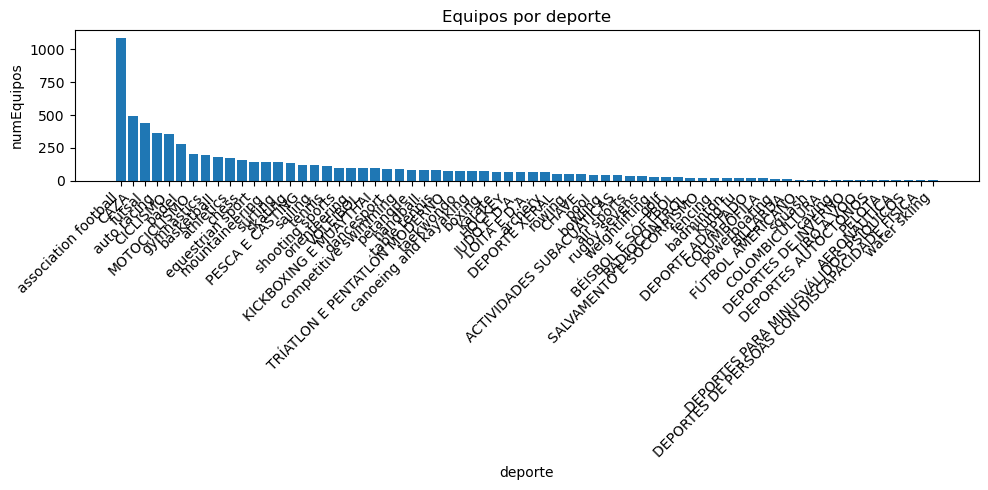

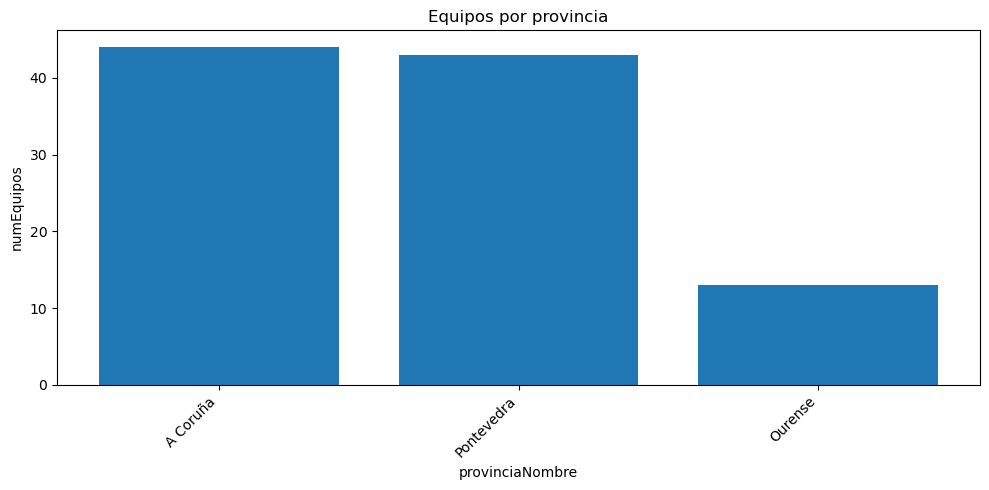

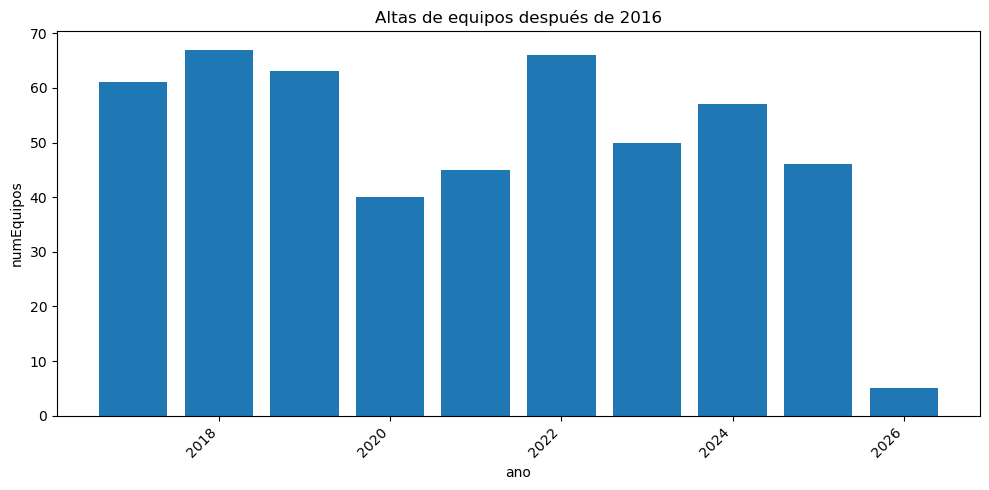

In [27]:
for df, xcol, ycol, title, fname in [
    (df_local_1, "deporte", "numEquipos", "Equipos por deporte", "equipos_por_provincia.png"),
    (df_local_2, "provinciaNombre", "numEquipos", "Equipos por provincia", "equipos_por_deporte.png"),
    (df_altas_ano, "ano", "numEquipos", "Altas de equipos después de 2016", "equipos_despues_2016.png")
]:
    data = df.copy()
    data[ycol] = pd.to_numeric(data[ycol], errors="coerce")
    plt.figure(figsize=(10, 5))
    plt.bar(data[xcol], data[ycol])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=180, bbox_inches="tight")
    plt.show()

## Federated query 1: provincias + enlace_wiki + coordenadas

In [47]:
query_prov_wikidata = """
PREFIX dep: <http://example.org/def/dep#>

SELECT ?provincia ?wikidata
WHERE {
  ?provincia a dep:Provincia ;
             dep:paxinaWeb ?wikidata .
}
"""

In [48]:
df_prov_wikidata = run_inline_query(query_prov_wikidata)
display(df_prov_wikidata)

,provincia,wikidata
0,http://example.org/resource/provincia/15,http://www.wikidata.org/entity/Q82119
1,http://example.org/resource/provincia/32,http://www.wikidata.org/entity/Q95038
2,http://example.org/resource/provincia/36,http://www.wikidata.org/entity/Q95086
3,http://example.org/resource/provincia/27,http://www.wikidata.org/entity/Q95027


In [49]:
#unimos con tabla local ya calculada
df_local_wd_counts = df_local_2.merge(df_prov_wikidata, on="provincia", how="left")
display(df_local_wd_counts)

,provincia,numEquipos,provinciaNombre,wikidata
0,http://example.org/resource/provincia/15,44,A Coruña,http://www.wikidata.org/entity/Q82119
1,http://example.org/resource/provincia/36,43,Pontevedra,http://www.wikidata.org/entity/Q95086
2,http://example.org/resource/provincia/32,13,Ourense,http://www.wikidata.org/entity/Q95038


In [50]:
import re

def extract_qid(uri):
    if pd.isna(uri):
        return None
    m = re.search(r'(Q\d+)$', str(uri))
    return m.group(1) if m else None

df_local_wd_counts["qid"] = df_local_wd_counts["wikidata"].apply(extract_qid)
display(df_local_wd_counts)

,provincia,numEquipos,provinciaNombre,wikidata,qid
0,http://example.org/resource/provincia/15,44,A Coruña,http://www.wikidata.org/entity/Q82119,Q82119
1,http://example.org/resource/provincia/36,43,Pontevedra,http://www.wikidata.org/entity/Q95086,Q95086
2,http://example.org/resource/provincia/32,13,Ourense,http://www.wikidata.org/entity/Q95038,Q95038


In [51]:
import requests
import pandas as pd
import re

#funcion de query_wikidata

def parse_point_wkt(wkt):
    if pd.isna(wkt):
        return None, None
    m = re.match(r"Point\(([-0-9.]+) ([-0-9.]+)\)", str(wkt))
    if not m:
        return None, None
    lon = float(m.group(1))
    lat = float(m.group(2))
    return lat, lon

def query_wikidata(qids, want_media=False):
    if not qids:
        return pd.DataFrame()

    values = " ".join(f"wd:{qid}" for qid in qids if qid)

    if want_media:
        query = f"""
        SELECT ?item ?itemLabel ?coord ?imagen ?web WHERE {{
          VALUES ?item {{ {values} }}

          OPTIONAL {{ ?item wdt:P625 ?coord . }}
          OPTIONAL {{ ?item wdt:P18 ?imagen . }}
          OPTIONAL {{ ?item wdt:P856 ?web . }}

          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "es,en". }}
        }}
        """
    else:
        query = f"""
        SELECT ?item ?itemLabel ?coord WHERE {{
          VALUES ?item {{ {values} }}

          OPTIONAL {{ ?item wdt:P625 ?coord . }}

          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "es,en". }}
        }}
        """

    url = "https://query.wikidata.org/sparql"
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "ChatGPT RDF project example"
    }
    response = requests.get(url, params={"query": query, "format": "json"}, headers=headers, timeout=60)
    response.raise_for_status()
    data = response.json()

    rows = []
    for b in data["results"]["bindings"]:
        item_uri = b["item"]["value"]
        qid = item_uri.split("/")[-1]
        label = b.get("itemLabel", {}).get("value")
        coord = b.get("coord", {}).get("value")
        lat, lon = parse_point_wkt(coord)

        row = {
            "qid": qid,
            "wikidata": item_uri,
            "label": label,
            "coord": coord,
            "lat": lat,
            "lon": lon,
        }

        if want_media:
            row["imagen"] = b.get("imagen", {}).get("value")
            row["web"] = b.get("web", {}).get("value")

        rows.append(row)

    return pd.DataFrame(rows)

In [52]:
import re

def extract_qid(uri):
    if pd.isna(uri):
        return None
    m = re.search(r'(Q\d+)$', str(uri))
    return m.group(1) if m else None

df_local_wd_counts["qid"] = df_local_wd_counts["wikidata"].apply(extract_qid)

qids = df_local_wd_counts["qid"].dropna().unique().tolist()
df_wikidata_geo = query_wikidata(qids, want_media=False)

df_fed_1 = df_local_wd_counts.merge(df_wikidata_geo, on="qid", how="left")
df_fed_1.to_csv(RESULTS_DIR / "federated_query_1.csv", index=False)
display(df_fed_1)

,provincia,numEquipos,provinciaNombre,wikidata_x,qid,wikidata_y,label,coord,lat,lon
0,http://example.org/resource/provincia/15,44,A Coruña,http://www.wikidata.org/entity/Q82119,Q82119,http://www.wikidata.org/entity/Q82119,provincia de La Coruña,Point(-8.4 43.37),43.370000,-8.400000
1,http://example.org/resource/provincia/36,43,Pontevedra,http://www.wikidata.org/entity/Q95086,Q95086,http://www.wikidata.org/entity/Q95086,provincia de Pontevedra,Point(-8.633333333 42.433333333),42.433333,-8.633333
2,http://example.org/resource/provincia/32,13,Ourense,http://www.wikidata.org/entity/Q95038,Q95038,http://www.wikidata.org/entity/Q95038,provincia de Orense,Point(-7.5 42.166666666),42.166667,-7.500000


In [53]:
import folium

def make_map(df, map_path):
    df_map = df.dropna(subset=["lat", "lon"]).copy()
    if df_map.empty:
        return None

    df_map["numEquipos"] = pd.to_numeric(df_map["numEquipos"], errors="coerce")

    center_lat = df_map["lat"].mean()
    center_lon = df_map["lon"].mean()

    m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

    for _, row in df_map.iterrows():
        nombre = row["provinciaNombre"] if "provinciaNombre" in df_map.columns else row["provincia"]

        popup = f"""
        <b>{nombre}</b><br>
        Equipos: {row['numEquipos']}<br>
        Wikidata: <a href="{row['wikidata']}" target="_blank">enlace</a>
        """

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=5 + float(row["numEquipos"]) / 20,
            popup=folium.Popup(popup, max_width=300),
            fill=True
        ).add_to(m)

    m.save(str(map_path))
    return m

In [55]:
print(df_fed_1.columns.tolist())
display(df_fed_1.head())

['provincia', 'numEquipos', 'provinciaNombre', 'wikidata_x', 'qid', 'wikidata_y', 'label', 'coord', 'lat', 'lon']


,provincia,numEquipos,provinciaNombre,wikidata_x,qid,wikidata_y,label,coord,lat,lon
0,http://example.org/resource/provincia/15,44,A Coruña,http://www.wikidata.org/entity/Q82119,Q82119,http://www.wikidata.org/entity/Q82119,provincia de La Coruña,Point(-8.4 43.37),43.370000,-8.400000
1,http://example.org/resource/provincia/36,43,Pontevedra,http://www.wikidata.org/entity/Q95086,Q95086,http://www.wikidata.org/entity/Q95086,provincia de Pontevedra,Point(-8.633333333 42.433333333),42.433333,-8.633333
2,http://example.org/resource/provincia/32,13,Ourense,http://www.wikidata.org/entity/Q95038,Q95038,http://www.wikidata.org/entity/Q95038,provincia de Orense,Point(-7.5 42.166666666),42.166667,-7.500000


In [56]:
df_fed_1 = df_fed_1.rename(columns={"wikidata_x": "wikidata"})
df_fed_1 = df_fed_1.drop(columns=["wikidata_y"])

In [57]:
from IPython.display import IFrame
map_path = MAPS_DIR / "map_provincias.html"
m = make_map(df_fed_1, map_path)

print("Mapa guardado en:", map_path)
if m is not None:
    display(IFrame(src=str(map_path), width=900, height=500))


Mapa guardado en: c:\Users\yarac\sw-kg\teams\coso\results\maps\map_provincias.html


## Federated query 2: informacion adicional de las concellos en wikidata (imagen, web oficial, etiqueta) (aunque aqui podria verse de usar los concellos o algo)

In [61]:
local_wd_uris_query = f'''
PREFIX dep: <http://example.org/def/dep#>
SELECT DISTINCT ?concello ?wikidata
WHERE {{
  ?concello a dep:Concello ;
            dep:paxinaWeb ?wikidata .
}}
ORDER BY ?concello
'''


In [62]:
df_local_wd_uris = run_inline_query(local_wd_uris_query)

from urllib.parse import unquote

def concello_nombre(uri):
    if pd.isna(uri):
        return None
    return unquote(str(uri).split("/")[-1])

df_local_wd_uris["concelloNombre"] = df_local_wd_uris["concello"].apply(concello_nombre)
df_local_wd_uris["qid"] = df_local_wd_uris["wikidata"].apply(extract_qid)

display(df_local_wd_uris)

,concello,wikidata,concelloNombre,qid
0,http://example.org/resource/concello/15001,http://www.wikidata.org/entity/Q318323,15001,Q318323
1,http://example.org/resource/concello/15002,http://www.wikidata.org/entity/Q1353997,15002,Q1353997
2,http://example.org/resource/concello/15003,http://www.wikidata.org/entity/Q1113417,15003,Q1113417
3,http://example.org/resource/concello/15004,http://www.wikidata.org/entity/Q17416,15004,Q17416
4,http://example.org/resource/concello/15005,http://www.wikidata.org/entity/Q996161,15005,Q996161
...,...,...,...,...
295,http://example.org/resource/concello/36059,http://www.wikidata.org/entity/Q1607479,36059,Q1607479
296,http://example.org/resource/concello/36060,http://www.wikidata.org/entity/Q1442637,36060,Q1442637
297,http://example.org/resource/concello/36061,http://www.wikidata.org/entity/Q739495,36061,Q739495
298,http://example.org/resource/concello/36901,http://www.wikidata.org/entity/Q300446,36901,Q300446


In [63]:
qids_media = df_local_wd_uris["qid"].dropna().unique().tolist()
df_wikidata_media = query_wikidata(qids_media, want_media=True)

display(df_wikidata_media)
print(df_wikidata_media.columns.tolist())

,qid,wikidata,label,coord,lat,lon,imagen,web
0,Q8745,http://www.wikidata.org/entity/Q8745,Vigo,Point(-8.726666666 42.235833333),42.235833,-8.726667,http://commons.wikimedia.org/wiki/Special:File...,http://vigo.gal
1,Q8757,http://www.wikidata.org/entity/Q8757,La Coruña,Point(-8.400027032 43.37385694),43.373857,-8.400027,http://commons.wikimedia.org/wiki/Special:File...,https://www.coruna.gal/
2,Q11125,http://www.wikidata.org/entity/Q11125,Lugo,Point(-7.557222222 43.011666666),43.011667,-7.557222,http://commons.wikimedia.org/wiki/Special:File...,http://concellodelugo.gal/
3,Q12411,http://www.wikidata.org/entity/Q12411,Pontevedra,Point(-8.6475 42.433611111),42.433611,-8.647500,http://commons.wikimedia.org/wiki/Special:File...,https://pontevedra.gal/
4,Q14314,http://www.wikidata.org/entity/Q14314,Santiago de Compostela,Point(-8.533333333 42.883333333),42.883333,-8.533333,http://commons.wikimedia.org/wiki/Special:File...,https://santiagodecompostela.gal/
...,...,...,...,...,...,...,...,...
307,Q1635664,http://www.wikidata.org/entity/Q1635664,Neda,Point(-8.1585283 43.5000016),43.500002,-8.158528,http://commons.wikimedia.org/wiki/Special:File...,http://www.neda.es
308,Q1644565,http://www.wikidata.org/entity/Q1644565,Oya,Point(-8.84424861 42.03254015),42.032540,-8.844249,http://commons.wikimedia.org/wiki/Special:File...,http://www.concellodeoia.es/
309,Q1644975,http://www.wikidata.org/entity/Q1644975,Lobera,Point(-8.043055555 41.998888888),41.998889,-8.043056,http://commons.wikimedia.org/wiki/Special:File...,http://www.lobeira.es/
310,Q1644983,http://www.wikidata.org/entity/Q1644983,La Lama,Point(-8.442307 42.396854),42.396854,-8.442307,http://commons.wikimedia.org/wiki/Special:File...,http://concellodalama.weebly.com/


['qid', 'wikidata', 'label', 'coord', 'lat', 'lon', 'imagen', 'web']


In [64]:
df_fed_2 = df_local_wd_uris.merge(df_wikidata_media, on="qid", how="left")
display(df_fed_2)
print(df_fed_2.columns.tolist())

,concello,wikidata_x,concelloNombre,qid,wikidata_y,label,coord,lat,lon,imagen,web
0,http://example.org/resource/concello/15001,http://www.wikidata.org/entity/Q318323,15001,Q318323,http://www.wikidata.org/entity/Q318323,Abegondo,Point(-8.288333333 43.2275),43.227500,-8.288333,http://commons.wikimedia.org/wiki/Special:File...,http://www.abegondo.es
1,http://example.org/resource/concello/15002,http://www.wikidata.org/entity/Q1353997,15002,Q1353997,http://www.wikidata.org/entity/Q1353997,Ames,Point(-8.65 42.86),42.860000,-8.650000,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
2,http://example.org/resource/concello/15002,http://www.wikidata.org/entity/Q1353997,15002,Q1353997,http://www.wikidata.org/entity/Q1353997,Ames,Point(-8.649594667 42.864976189),42.864976,-8.649595,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
3,http://example.org/resource/concello/15002,http://www.wikidata.org/entity/Q1353997,15002,Q1353997,http://www.wikidata.org/entity/Q1353997,Ames,Point(-8.672325391 42.89015995),42.890160,-8.672325,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
4,http://example.org/resource/concello/15003,http://www.wikidata.org/entity/Q1113417,15003,Q1113417,http://www.wikidata.org/entity/Q1113417,Aranga,Point(-8.015833333 43.233888888),43.233889,-8.015833,http://commons.wikimedia.org/wiki/Special:File...,http://www.aranga.es/
...,...,...,...,...,...,...,...,...,...,...,...
307,http://example.org/resource/concello/36059,http://www.wikidata.org/entity/Q1607479,36059,Q1607479,http://www.wikidata.org/entity/Q1607479,Villa de Cruces,Point(-8.1682653 42.7950805),42.795080,-8.168265,http://commons.wikimedia.org/wiki/Special:File...,http://www.viladecruces.org/
308,http://example.org/resource/concello/36060,http://www.wikidata.org/entity/Q1442637,36060,Q1442637,http://www.wikidata.org/entity/Q1442637,Villagarcía de Arosa,Point(-8.743064672 42.5950581),42.595058,-8.743065,http://commons.wikimedia.org/wiki/Special:File...,https://vilagarcia.gal
309,http://example.org/resource/concello/36061,http://www.wikidata.org/entity/Q739495,36061,Q739495,http://www.wikidata.org/entity/Q739495,Villanueva de Arosa,Point(-8.8299345 42.5626279),42.562628,-8.829935,http://commons.wikimedia.org/wiki/Special:File...,http://www.vilanovadearousa.com/
310,http://example.org/resource/concello/36901,http://www.wikidata.org/entity/Q300446,36901,Q300446,http://www.wikidata.org/entity/Q300446,Isla de Arosa,Point(-8.863888888 42.554444444),42.554444,-8.863889,http://commons.wikimedia.org/wiki/Special:File...,http://www.ailladearousa.es/


['concello', 'wikidata_x', 'concelloNombre', 'qid', 'wikidata_y', 'label', 'coord', 'lat', 'lon', 'imagen', 'web']


In [65]:
if "wikidata_x" in df_fed_2.columns:
    df_fed_2 = df_fed_2.rename(columns={"wikidata_x": "wikidata"})
if "wikidata_y" in df_fed_2.columns:
    df_fed_2 = df_fed_2.drop(columns=["wikidata_y"])

In [66]:
df_fed_2.to_csv(RESULTS_DIR / "federated_query_2.csv", index=False)
display(df_fed_2[["concelloNombre", "wikidata", "label", "imagen", "web"]])

,concelloNombre,wikidata,label,imagen,web
0,15001,http://www.wikidata.org/entity/Q318323,Abegondo,http://commons.wikimedia.org/wiki/Special:File...,http://www.abegondo.es
1,15002,http://www.wikidata.org/entity/Q1353997,Ames,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
2,15002,http://www.wikidata.org/entity/Q1353997,Ames,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
3,15002,http://www.wikidata.org/entity/Q1353997,Ames,http://commons.wikimedia.org/wiki/Special:File...,https://www.concellodeames.gal
4,15003,http://www.wikidata.org/entity/Q1113417,Aranga,http://commons.wikimedia.org/wiki/Special:File...,http://www.aranga.es/
...,...,...,...,...,...
307,36059,http://www.wikidata.org/entity/Q1607479,Villa de Cruces,http://commons.wikimedia.org/wiki/Special:File...,http://www.viladecruces.org/
308,36060,http://www.wikidata.org/entity/Q1442637,Villagarcía de Arosa,http://commons.wikimedia.org/wiki/Special:File...,https://vilagarcia.gal
309,36061,http://www.wikidata.org/entity/Q739495,Villanueva de Arosa,http://commons.wikimedia.org/wiki/Special:File...,http://www.vilanovadearousa.com/
310,36901,http://www.wikidata.org/entity/Q300446,Isla de Arosa,http://commons.wikimedia.org/wiki/Special:File...,http://www.ailladearousa.es/


Opción 2: mostrar una tabla más bonita en el notebook

Puedes crear una tabla HTML donde:

el nombre del concello salga normal
la URL web salga como enlace clicable
la imagen salga como miniatura

In [67]:
from IPython.display import HTML

df_show = df_fed_2[["label", "imagen", "web"]].copy()

def make_img(url):
    if pd.isna(url):
        return ""
    return f'<img src="{url}" width="120">'

def make_link(url):
    if pd.isna(url):
        return ""
    return f'<a href="{url}" target="_blank">{url}</a>'

df_show["imagen"] = df_show["imagen"].apply(make_img)
df_show["web"] = df_show["web"].apply(make_link)

HTML(df_show.head(12).to_html(escape=False, index=False))

label,imagen,web
Abegondo,,http://www.abegondo.es
Ames,,https://www.concellodeames.gal
Ames,,https://www.concellodeames.gal
Ames,,https://www.concellodeames.gal
Aranga,,http://www.aranga.es/
Ares,,http://www.concellodeares.gal
Arteijo,,http://www.arteixo.org/
Arzúa,,http://www.concellodearzua.org/
La Baña,,https://concellodabana.gal/
Bergondo,,http://www.concellodebergondo.com/


## Interpretación sugerida para tu memoria (mejorar este texto)

- **Consulta local 1**: permite ver la distribución territorial de los equipos.
- **Consulta local 2**: muestra qué deportes están más representados en los datos.
- **Consulta por fecha**: ayuda a analizar la evolución reciente de las altas.
- **Consulta federada 1**: enriquece el análisis territorial con coordenadas y población de Wikidata.
- **Consulta federada 2**: añade recursos descriptivos externos como imagen o web oficial.

Si alguna propiedad de tu ontología tiene otro nombre, solo tienes que ajustar las IRIs usadas en las celdas o en los archivos `.rq`.
